<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 30)

data_path = Path('online_retail_II.csv')

df = pd.read_csv(data_path, encoding='ISO-8859-1')

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
})

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('Первые строки датасета:')
display(df.head())
print('Размер данных:', df.shape)
print('\nТипы данных:')
print(df.dtypes)
print('\nПропущенные значения:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))
print('Общий объем продаж до очистки, с учетом возвратов:', round(df['TotalPrice'].sum(), 2))
print('Количество клиентов:', df['CustomerID'].nunique())
print('Количество транзакций:', df['InvoiceNo'].nunique())

purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

print('\nЧастота покупок по клиентам:')
display(purchase_frequency.describe().to_frame('frequency'))

product_revenue = (
    df.groupby('Description', dropna=False)['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print('\nТоп-10 товаров по выручке:')
display(product_revenue.to_frame('revenue'))

anomalies = df[
    (df['Quantity'] <= 0) |
    (df['UnitPrice'] <= 0) |
    (df['CustomerID'].isna())
]

print('\nПотенциальные аномалии:', len(anomalies))
display(anomalies.head())

Первые строки датасета:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Размер данных: (1067371, 9)

Типы данных:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object

Пропущенные значения:


,missing
CustomerID,243007
Description,4382
InvoiceNo,0
Quantity,0
StockCode,0
InvoiceDate,0
UnitPrice,0
Country,0
TotalPrice,0


Общий объем продаж до очистки, с учетом возвратов: 19287250.57
Количество клиентов: 5942
Количество транзакций: 53628

Частота покупок по клиентам:


,frequency
count,5942.000000
mean,7.552339
std,15.972262
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,510.000000



Топ-10 товаров по выручке:


,revenue
Description,
REGENCY CAKESTAND 3 TIER,327813.65
DOTCOM POSTAGE,322647.47
WHITE HANGING HEART T-LIGHT HOLDER,257533.90
JUMBO BAG RED RETROSPOT,148800.64
PARTY BUNTING,147948.50
ASSORTED COLOUR BIRD ORNAMENT,131413.85
PAPER CHAIN KIT 50'S CHRISTMAS,121662.14
POSTAGE,112341.00
CHILLI LIGHTS,84854.16



Потенциальные аномалии: 261822


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [2]:
from sklearn.preprocessing import StandardScaler

missing_before = df.isna().sum()

data = df.copy()

data['Description'] = data['Description'].fillna('Unknown')

rows_initial = len(data)

critical_columns = ['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice']
data = data.dropna(subset=critical_columns)
removed_missing = rows_initial - len(data)

rows_after_missing = len(data)

data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
removed_cancelled = rows_after_missing - len(data)

rows_after_cancelled = len(data)

data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)].copy()
removed_invalid = rows_after_cancelled - len(data)

data['CustomerID'] = data['CustomerID'].astype(int)
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

data_clean = data.copy()

snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

invoice_sum = data_clean.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
avg_check = invoice_sum.groupby('CustomerID')['TotalPrice'].mean().rename('AvgCheck')

rfm = data_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    Quantity=('Quantity', 'sum'),
    UniqueItems=('StockCode', 'nunique')
).join(avg_check)

rfm['Country'] = data_clean.groupby('CustomerID')['Country'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
)

rfm = rfm.replace([np.inf, -np.inf], np.nan).dropna()

features = ['Recency', 'Frequency', 'Monetary', 'AvgCheck', 'Quantity', 'UniqueItems']

rfm_before_outliers = rfm.copy()
outlier_limits = rfm[features].quantile([0.01, 0.99])

for feature in features:
    rfm[feature] = rfm[feature].clip(
        lower=outlier_limits.loc[0.01, feature],
        upper=outlier_limits.loc[0.99, feature]
    )

customers_with_capped_values = (rfm_before_outliers[features] != rfm[features]).any(axis=1).sum()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])
X_scaled = pd.DataFrame(X_scaled, columns=features, index=rfm.index)

print('Пропуски до обработки:')
display(missing_before.sort_values(ascending=False).to_frame('missing_before'))

cleaning_summary = pd.DataFrame({
    'Этап': [
        'Исходные строки',
        'Удалены строки без CustomerID или критических полей',
        'Удалены отмененные заказы',
        'Удалены строки с Quantity <= 0 или UnitPrice <= 0',
        'Осталось строк после очистки'
    ],
    'Количество строк': [
        rows_initial,
        removed_missing,
        removed_cancelled,
        removed_invalid,
        len(data_clean)
    ]
})

display(cleaning_summary)
print('Всего удалено строк:', rows_initial - len(data_clean))
print('Количество клиентов в RFM-таблице:', len(rfm))
print('Количество клиентов, у которых были ограничены экстремальные RFM-значения:', customers_with_capped_values)

print('\nRFM-признаки:')
display(rfm.head())

print('\nМетод масштабирования: StandardScaler. Он выбран, потому что K-Means, иерархическая кластеризация, DBSCAN и OPTICS зависят от расстояний, а стандартизация приводит признаки RFM к единому масштабу')
display(X_scaled.describe().round(3))

Пропуски до обработки:


,missing_before
CustomerID,243007
Description,4382
InvoiceNo,0
Quantity,0
StockCode,0
InvoiceDate,0
UnitPrice,0
Country,0
TotalPrice,0


,Этап,Количество строк
0,Исходные строки,1067371
1,Удалены строки без CustomerID или критических ...,243007
2,Удалены отмененные заказы,18744
3,Удалены строки с Quantity <= 0 или UnitPrice <= 0,71
4,Осталось строк после очистки,805549


Всего удалено строк: 261822
Количество клиентов в RFM-таблице: 5878
Количество клиентов, у которых были ограничены экстремальные RFM-значения: 324

RFM-признаки:


,Recency,Frequency,Monetary,Quantity,UniqueItems,AvgCheck,Country
CustomerID,,,,,,,
12346,326,12,29730.4202,17491.68,27.0,1994.986033,United Kingdom
12347,2,8,5633.3200,3286.00,126.0,704.165000,Iceland
12348,75,5,2019.4000,2714.00,25.0,403.880000,Finland
12349,19,4,4428.6900,1624.00,138.0,1107.172500,Italy
12350,310,1,334.4000,197.00,17.0,334.400000,Norway



Метод масштабирования: StandardScaler. Он выбран, потому что K-Means, иерархическая кластеризация, DBSCAN и OPTICS зависят от расстояний, а стандартизация приводит признаки RFM к единому масштабу


,Recency,Frequency,Monetary,AvgCheck,Quantity,UniqueItems
count,5878.000,5878.000,5878.000,5878.000,5878.000,5878.000
mean,-0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.958,-0.627,-0.532,-1.069,-0.532,-0.827
25%,-0.838,-0.627,-0.462,-0.588,-0.459,-0.637
50%,-0.503,-0.365,-0.335,-0.242,-0.341,-0.363
75%,0.855,0.159,-0.011,0.212,0.007,0.249
max,2.509,5.271,6.311,5.484,6.344,4.464


#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эвристического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

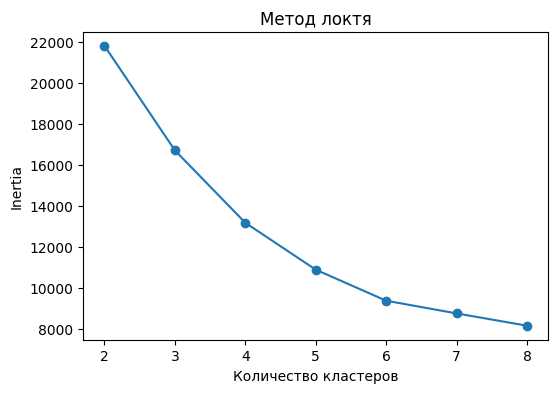

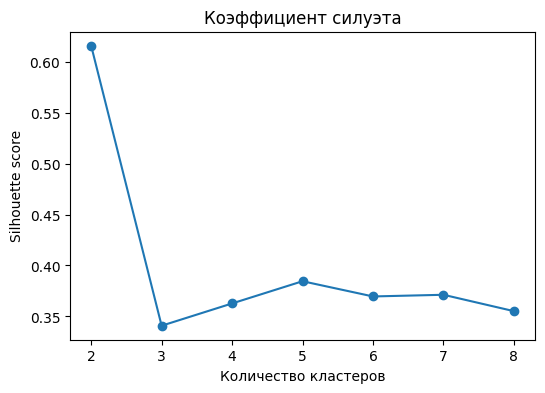

Количество кластеров для итоговой сегментации: 3
eps для DBSCAN и OPTICS: 0.6618


,KMeans_cluster,Hierarchical_cluster,DBSCAN_cluster,OPTICS_cluster
CustomerID,,,,
12346,0,0,-1,-1
12347,2,1,0,-1
12348,2,1,0,-1
12349,2,1,0,-1
12350,1,1,0,-1


In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

features = ['Recency', 'Frequency', 'Monetary', 'AvgCheck', 'Quantity', 'UniqueItems']

X_model = X_scaled.values

ks = range(2, 9)

inertia = []
silhouette = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_model)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_model, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(ks), inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(ks), silhouette, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette score')
plt.title('Коэффициент силуэта')
plt.show()

best_k = 3

rfm['KMeans_cluster'] = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
).fit_predict(X_model)

rfm['Hierarchical_cluster'] = AgglomerativeClustering(
    n_clusters=best_k
).fit_predict(X_model)

distances, indices = NearestNeighbors(n_neighbors=5, n_jobs=-1).fit(X_model).kneighbors(X_model)
eps_value = np.percentile(np.sort(distances[:, 4]), 90)

rfm['DBSCAN_cluster'] = DBSCAN(
    eps=eps_value,
    min_samples=5,
    n_jobs=-1
).fit_predict(X_model)

rfm['OPTICS_cluster'] = OPTICS(
    min_samples=5,
    max_eps=eps_value
).fit_predict(X_model)

print('Количество кластеров для итоговой сегментации:', best_k)
print('eps для DBSCAN и OPTICS:', round(eps_value, 4))

display(rfm[['KMeans_cluster', 'Hierarchical_cluster', 'DBSCAN_cluster', 'OPTICS_cluster']].head())

#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [4]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

cluster_columns = {
    'KMeans': 'KMeans_cluster',
    'Hierarchical': 'Hierarchical_cluster',
    'DBSCAN': 'DBSCAN_cluster',
    'OPTICS': 'OPTICS_cluster'
}

results = []

for name, column in cluster_columns.items():
    labels = rfm[column].values

    noise_count = int((labels == -1).sum())
    noise_share = noise_count / len(labels)

    mask = labels != -1
    labels_eval = labels[mask]
    X_eval = X_model[mask]

    if len(set(labels_eval)) > 1:
        results.append({
            'Алгоритм': name,
            'Silhouette': silhouette_score(X_eval, labels_eval),
            'Davies-Bouldin': davies_bouldin_score(X_eval, labels_eval),
            'Calinski-Harabasz': calinski_harabasz_score(X_eval, labels_eval),
            'Количество кластеров': len(set(labels_eval)),
            'Шум': noise_count,
            'Доля шума': round(noise_share, 4)
        })

metrics_df = pd.DataFrame(results)
display(metrics_df)

best_by_silhouette = metrics_df.sort_values('Silhouette', ascending=False).iloc[0]['Алгоритм']

best_algorithm = 'KMeans'
rfm['BestCluster'] = rfm['KMeans_cluster']

print('Лучший алгоритм по Silhouette:', best_by_silhouette)
print('Итоговый алгоритм для бизнес-сегментации:', best_algorithm)
print('Причина выбора: KMeans дает 3 нормальных сегмента клиентов без шума -1. (DBSCAN/OPTICS выделили большую часть клиентов как шум с меткой -1, поэтому такой результат сложно использовать для бизнес-рекомендаций. KMeans разделил всех клиентов на 3 понятных сегмента, поэтому он лучше подходит для дальнейшего анализа)')
print('Внешние метрики ARI и NMI не рассчитываются, так как в датасете нет истинных меток классов')

,Алгоритм,Silhouette,Davies-Bouldin,Calinski-Harabasz,Количество кластеров,Шум,Доля шума
0,KMeans,0.340869,1.036692,3267.092503,3,0,0.0000
1,Hierarchical,0.304989,1.016297,2760.776926,3,0,0.0000
2,DBSCAN,0.523716,0.521077,131.500752,9,450,0.0766
3,OPTICS,0.473900,0.678832,966.959020,149,4685,0.7970


Лучший алгоритм по Silhouette: DBSCAN
Итоговый алгоритм для бизнес-сегментации: KMeans
Причина выбора: KMeans дает 3 нормальных сегмента клиентов без шума -1. (DBSCAN/OPTICS выделили большую часть клиентов как шум с меткой -1, поэтому такой результат сложно использовать для бизнес-рекомендаций. KMeans разделил всех клиентов на 3 понятных сегмента, поэтому он лучше подходит для дальнейшего анализа)
Внешние метрики ARI и NMI не рассчитываются, так как в датасете нет истинных меток классов


#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

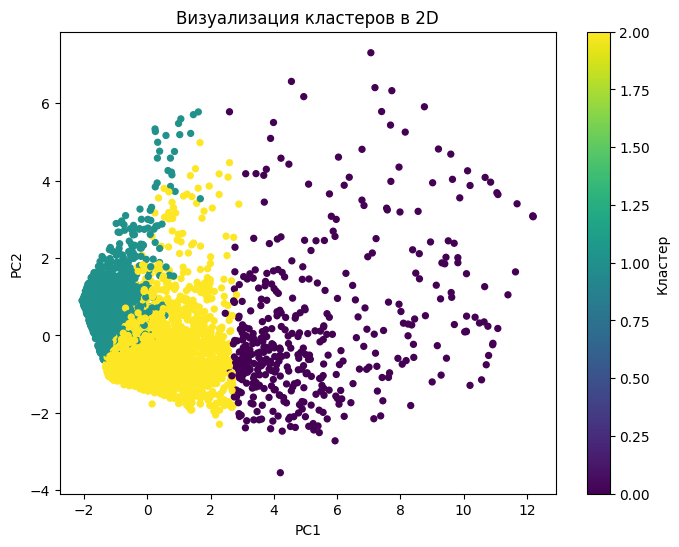

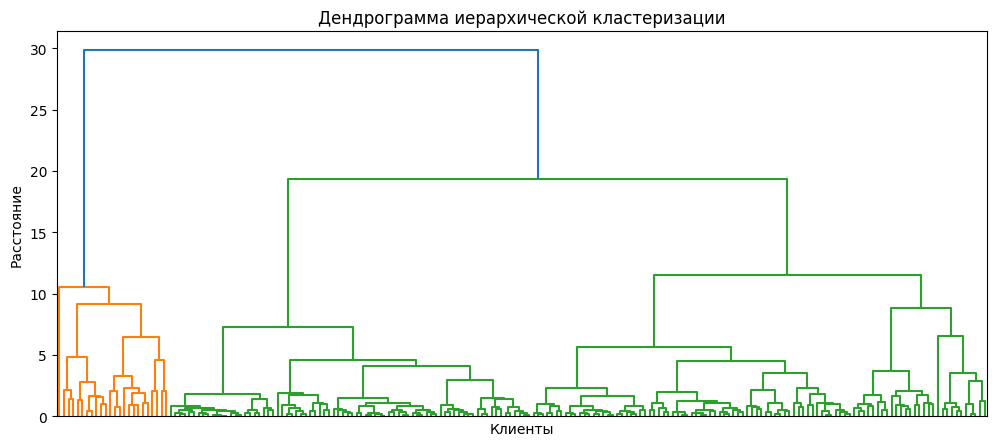

,Recency,Frequency,Monetary,AvgCheck,Quantity,UniqueItems,CustomerCount,MainCountry,SegmentName
BestCluster,,,,,,,,,
0,41.52,25.53,14648.91,708.53,8443.95,274.23,431,United Kingdom,Ценные активные клиенты
1,448.57,2.01,597.11,293.81,325.30,31.15,2088,United Kingdom,Покупатели со сниженной активностью
2,68.02,5.60,1866.95,351.85,1091.48,84.40,3359,United Kingdom,Обычные активные покупатели


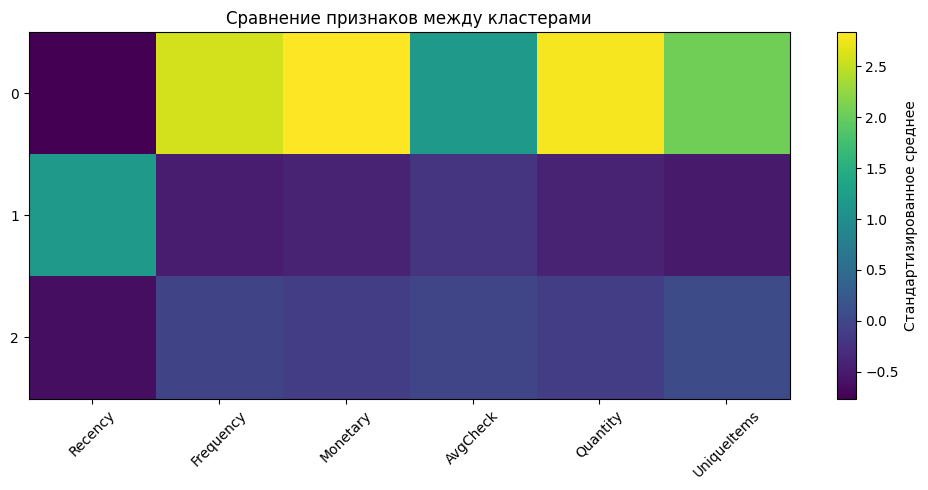

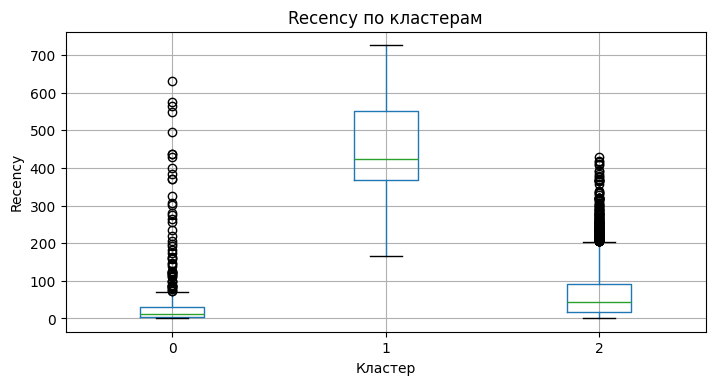

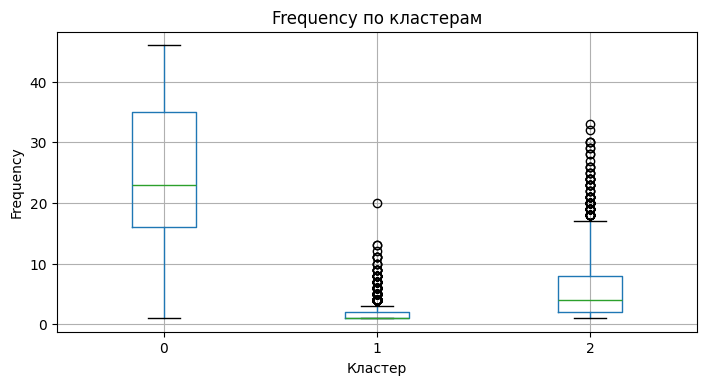

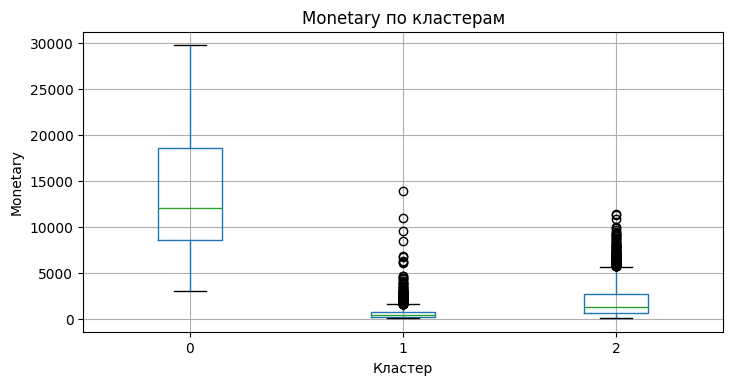

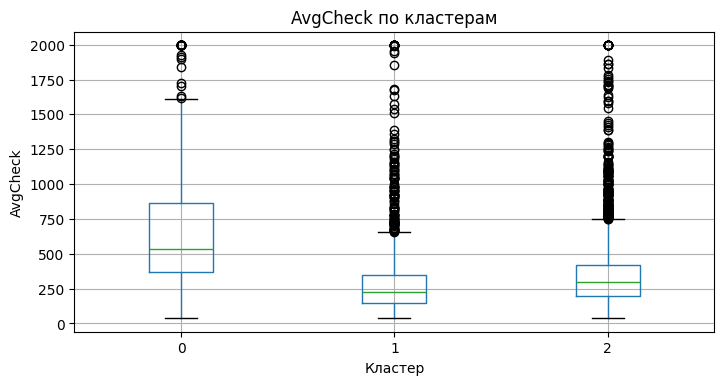

Кластер 0: Ценные активные клиенты. Средние значения: Recency=41.52, Frequency=25.53, Monetary=14648.91, AvgCheck=708.53. Основная страна клиентов: United Kingdom. Количество клиентов: 431.
Кластер 1: Покупатели со сниженной активностью. Средние значения: Recency=448.57, Frequency=2.01, Monetary=597.11, AvgCheck=293.81. Основная страна клиентов: United Kingdom. Количество клиентов: 2088.
Кластер 2: Обычные активные покупатели. Средние значения: Recency=68.02, Frequency=5.6, Monetary=1866.95, AvgCheck=351.85. Основная страна клиентов: United Kingdom. Количество клиентов: 3359.


In [5]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

rfm['BestCluster'] = rfm['KMeans_cluster']

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_model)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=rfm['BestCluster'], s=18)
plt.title('Визуализация кластеров в 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Кластер')
plt.show()

sample_size = min(200, len(X_model))
sample_idx = np.random.default_rng(42).choice(len(X_model), size=sample_size, replace=False)

linked = linkage(X_model[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, no_labels=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.show()

cluster_profiles = rfm.groupby('BestCluster')[features].mean().round(2)

cluster_profiles['CustomerCount'] = rfm['BestCluster'].value_counts().sort_index()

if 'Country' in rfm.columns:
    country_info = (
        rfm.groupby('BestCluster')['Country']
        .agg(lambda x: x.value_counts().index[0])
    )

else:
    if 'CustomerID' in rfm.columns:
        customer_clusters = rfm[['CustomerID', 'BestCluster']].copy()
    else:
        customer_clusters = rfm[['BestCluster']].copy()
        customer_clusters['CustomerID'] = customer_clusters.index

    df_with_clusters = df_clean.merge(
        customer_clusters[['CustomerID', 'BestCluster']],
        on='CustomerID',
        how='inner'
    )

    country_info = (
        df_with_clusters.groupby('BestCluster')['Country']
        .agg(lambda x: x.value_counts().index[0])
    )

cluster_profiles['MainCountry'] = country_info

segment_names = {
    0: 'Ценные активные клиенты',
    1: 'Покупатели со сниженной активностью',
    2: 'Обычные активные покупатели'
}

rfm['SegmentName'] = rfm['BestCluster'].map(segment_names)
cluster_profiles['SegmentName'] = cluster_profiles.index.map(segment_names)

display(cluster_profiles)

profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profiles[features]),
    columns=features,
    index=cluster_profiles.index
)

plt.figure(figsize=(10, 5))
plt.imshow(profile_scaled, aspect='auto')
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(profile_scaled.index)), profile_scaled.index)
plt.colorbar(label='Стандартизированное среднее')
plt.title('Сравнение признаков между кластерами')
plt.tight_layout()
plt.show()

for feature in ['Recency', 'Frequency', 'Monetary', 'AvgCheck']:
    rfm.boxplot(column=feature, by='BestCluster', figsize=(8, 4))
    plt.title(feature + ' по кластерам')
    plt.suptitle('')
    plt.xlabel('Кластер')
    plt.ylabel(feature)
    plt.show()

for cluster_id, row in cluster_profiles.iterrows():
    print(
        f"Кластер {cluster_id}: {row['SegmentName']}. "
        f"Средние значения: Recency={row['Recency']}, "
        f"Frequency={row['Frequency']}, "
        f"Monetary={row['Monetary']}, "
        f"AvgCheck={row['AvgCheck']}. "
        f"Основная страна клиентов: {row['MainCountry']}. "
        f"Количество клиентов: {int(row['CustomerCount'])}."
    )

#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

**Кластер 0 - ценные активные клиенты:**

В этот кластер попал 431 клиент. Это самая ценная группа, потому что у них самая высокая частота покупок, самая большая сумма покупок и самый высокий средний чек. Эти клиенты покупали недавно и активно взаимодействуют с магазином. Для них лучше использовать персональные предложения, бонусы за повторные покупки, программу лояльности и ранний доступ к новым товарам. Также им можно предлагать более дорогие товары или наборы, потому что они уже готовы тратить больше. Такие действия помогут удержать самых прибыльных клиентов и сохранить основную часть выручки.

**Кластер 1 - покупатели со сниженной активностью:**

В этот кластер попало 2088 клиентов. У них самая большая давность последней покупки, низкая частота заказов и самая маленькая сумма покупок. Это значит, что клиенты давно не покупали и есть риск, что они больше не вернутся. Для этого сегмента лучше использовать простые реактивационные предложения: промокод на следующий заказ, скидку на популярные товары или письмо-напоминание. Главная цель - вернуть этих клиентов к покупке. Если хотя бы часть клиентов снова сделает заказ, это поможет снизить отток и увеличить количество активных покупателей.

**Кластер 2 - обычные активные покупатели:**

В этот кластер попало больше всего клиентов - 3359 человек. Они покупали относительно недавно, но не так часто и не на такие большие суммы, как клиенты из кластера 0. Это основная часть клиентской базы, которую можно развивать. Для них подойдут скидки на повторную покупку, подборки популярных товаров и предложения на сопутствующие товары. Также можно использовать простую программу лояльности, чтобы мотивировать их покупать чаще. Это может повысить средний чек и общую выручку магазина.

#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Описание цели работы и её значимости для бизнеса.
- **Методология:**
  - Подробное описание проведенных шагов.
- **Результаты:**
  - Представление метрик оценки и визуализаций.
  - Описание сегментов клиентов.
- **Обсуждение:**
  - Анализ полученных результатов.
  - Сравнение алгоритмов и обоснование выбора.
- **Рекомендации:**
  - Предложения по внедрению результатов в бизнес-процессы.
- **Заключение:**
  - Выводы о проделанной работе и её значимости.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.



# **Введение**
Цель работы - выполнить сегментацию клиентов интернет-магазина по датасету  "Online Retail II". Это важно для бизнеса, потому что разные группы клиентов требуют разных предложений и подходов.

# **Методология**
Сначала были загружены и изучены данные: количество строк, пропуски, клиенты, транзакции и общий объем продаж. Затем была выполнена очистка: удалены строки без `CustomerID`, отмененные заказы и записи с некорректным количеством или ценой. После этого были рассчитаны RFM-признаки: `Recency`, `Frequency`, `Monetary`, а также средний чек, количество товаров и уникальные товары. Перед кластеризацией признаки были масштабированы.

# **Результаты**
Были применены KMeans, иерархическая кластеризация, DBSCAN и OPTICS. Для оценки использовались `Silhouette Score`, `Davies-Bouldin Index` и `Calinski-Harabasz Index`. Также были построены PCA-график, дендрограмма, график сравнения признаков и boxplot-графики. В итоговой сегментации KMeans получилось 3 кластера:

**Кластер 0 - ценные активные клиенты**: покупают часто, недавно и приносят больше всего выручки.

**Кластер 1 - покупатели со сниженной активностью**: давно не покупали, имеют низкую частоту и меньшую сумму покупок.

**Кластер 2 - обычные активные покупатели**: самая большая группа со средними показателями.

# **Обсуждение**
KMeans был выбран для итоговой сегментации, потому что он дал 3 понятные группы без кластера `-1`. DBSCAN и OPTICS хуже подходят для бизнес-интерпретации, так как могут выделять много клиентов как шум.

# **Рекомендации**
Для кластера 0 нужно использовать бонусы, программу лояльности и персональные предложения. Для кластера 1 - промокоды, скидки и напоминания, чтобы вернуть клиентов. Для кластера 2 - скидки на повторные покупки и предложения популярных товаров.

# **Заключение**
В работе были очищены данные, рассчитаны признаки клиентов, применены алгоритмы кластеризации и выделены 3 сегмента. Эти результаты можно использовать для удержания клиентов, персонализации предложений и повышения продаж.